#### Name: 

# PHYS 230 Lab Assignment 10

### Wednesday, February 25, 2026: Chapter 5.10-5.12
- Evaluating derivatives in python 
- Automatic Differentiation (& Interpolation)

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [64]:
# put all import statements here
import numpy as np
import math as m
import matplotlib.pyplot as plt

## Derivatives with front, back, and central difference (25 pts)

Let's evaluate the derivative of: 

$$ f(x) = \frac{1-\cos x}{x^2} $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the function `f(x)` that returns the function $f(x)$ from above. 

In [ ]:
def f(x): #definition of our function
    return (1-np.cos(x))/(x**2)

#### Step 2: Define functions that call on your function from step 1 to calculate the front, back, and central difference first derivatives of $f(x)$ at a specific location $x$. 

In [ ]:
def cd_diff(x,h,f):#definition of central difference
    return (f(x+h)-f(x-h))/(2*h)
def bwd_diff(x,h,f):#definition of backward
    return (f(x)-f(x-h))/(h)
def fwd_diff(x,h,f):#definition of forward
    return (f(x+h)-f(x))/(h)

Input_x = float(input("Input x value: ")) #Taking in input x-value for specific x

simp_h_diff = 1e-10 #our h-value for backward/forward difference
h_diff = 1e-8       #our h-value for central difference 

print("Backward:", bwd_diff(Input_x,simp_h_diff,f)) #Printing results
print("Central: ", cd_diff(Input_x,h_diff,f))
print("Forward: ", fwd_diff(Input_x,simp_h_diff,f))


Backward: -0.00911836578465497
Central:  -0.00911835485589707
Forward:  -0.00911836578465497


#### Step 3: Evaluate the derivative using the three different approximations using the appropriate value of $h$ for each method evaluated from $x = 0.004$ to $x = \frac{\pi}{2}$ - let's do 20 calculations. 

In [ ]:
X_array = np.linspace(0.004,np.pi/4,20) #Defining our x-values

simp_h_diff = 1e-10 #our h-value for backward/forward difference
h_diff = 1e-8       #our h-value for central difference 

print("Backward:", bwd_diff(X_array,simp_h_diff,f)) #Printing results
print("Central: ", cd_diff(X_array,h_diff,f))
print("Forward: ", fwd_diff(X_array,simp_h_diff,f))

Backward: [ 0.00868472 -0.00391964 -0.00718314 -0.01056877 -0.01403433 -0.01741773
 -0.02081835 -0.02418676 -0.02755018 -0.03088585 -0.03420486 -0.03751
 -0.04078127 -0.04402534 -0.04724277 -0.05042688 -0.05357659 -0.05668965
 -0.05976664 -0.0628031 ]
Central:  [-0.00033987 -0.00376057 -0.00718377 -0.01060371 -0.01401544 -0.01741822
 -0.02080898 -0.02418579 -0.02754625 -0.03088811 -0.0342092  -0.03750718
 -0.04077994 -0.04402524 -0.04724098 -0.05042499 -0.05357518 -0.0566895
 -0.05976591 -0.06280239]
Forward:  [ 0.00867806 -0.00391798 -0.0071837  -0.0106376  -0.01399492 -0.01741884
 -0.02080225 -0.024174   -0.02753964 -0.03089362 -0.03421097 -0.03750389
 -0.04078127 -0.04402645 -0.04723999 -0.05042355 -0.05357381 -0.05668965
 -0.05976497 -0.0628031 ]


#### Step 4: Determine the equation for the derivative (by hand and then type in below this cell as markdown). Computationally calculate the true value of the derivative at the range of values from step 3 and compare to your calculated values. Explain your results in a markdown cell. 

$$\left(\frac{\sin\left(x\right)}{x^{2}}-\frac{\sin^{2}\left(\frac{x}{2}\right)}{4x^{3}}\right)$$

In [ ]:
def f_div(x): #Defining the true derivative function
    return 4*(np.sin(x)/(4*x**2) - ((np.sin(x/2))**2)/(x**3))
true_val = f_div(X_array) #Calling the true derivative values

bwd_error = abs(bwd_diff(X_array,simp_h_diff,f)-true_val) #Calculating the absolute value errors of our computed results vs actual
cd_error = abs(cd_diff(X_array,h_diff,f)-true_val)
fwd_error = abs(fwd_diff(X_array,simp_h_diff,f)-true_val)

bwd_t_err = sum(bwd_error) #Summing the errors
cd_t_err = sum(cd_error)
fwd_t_err = sum(fwd_error)
t_err = [bwd_t_err,cd_t_err,fwd_t_err] #Making a list of the total errors

Word_err = ["Backward", "Central", "Forward" ] #Word list

print(Word_err[0],"error:", bwd_error) #Printing out methods and their associated errors
print(Word_err[1],"error:", cd_error)
print(Word_err[2],"error:", fwd_error)

print("Lowest error given by",Word_err[t_err.index(min(t_err))], "running total of:", min(t_err)) #Printing the best method and its cumulative error

Backward error: [6.20770605e-07 4.76031196e-08 1.99215328e-07 8.75824662e-08
 2.21211083e-07 2.72928992e-07 2.68455280e-07 2.60147553e-08
 4.17911706e-07 8.48546959e-07 8.80425457e-07 8.26718372e-07
 1.16860862e-06 8.18954625e-07 6.36142149e-07 1.77247626e-06
 1.73326920e-07 3.81018654e-06 1.63328748e-05 2.29425823e-04
 2.29980935e-04 1.63328748e-05 4.36529805e-06 7.28438433e-07
 1.77247626e-06 4.91497297e-06 2.63843112e-07 1.16860862e-06
 2.71606859e-07 2.29797567e-07 8.48546959e-07 9.73023218e-07
 2.60147553e-08 2.86656233e-07 2.82182520e-07 2.21211083e-07
 8.75824663e-08 1.99215328e-07 1.06261991e-06 4.89452420e-07]
Central error: [4.59682603e-09 5.13247406e-09 6.24816032e-10 1.23537580e-09
 3.60907937e-09 9.24351373e-10 7.73803799e-10 1.03473730e-09
 1.57807167e-09 6.32476960e-09 3.34926797e-09 3.97781585e-10
 2.67667200e-09 1.65143899e-10 7.78720510e-09 2.38749958e-08
 4.28757145e-08 5.61651445e-08 2.92497138e-08 3.13461544e-06
 2.87647030e-07 2.92497138e-08 5.61651445e-08 2.65132

#### Step 5: Evalute the derivative using the three approximations with a value of $h=10^{-6}$. Compare (computationally and in markdown) the values with each other and the true value. 

In [ ]:
h = 1e-6 #h-value
bwd_error = abs(bwd_diff(X_array,h,f)-true_val) #Errors
cd_error = abs(cd_diff(X_array,h,f)-true_val)
fwd_error = abs(fwd_diff(X_array,h,f)-true_val)

bwd_t_err = sum(bwd_error) #Total error for each
cd_t_err = sum(cd_error)
fwd_t_err = sum(fwd_error)
t_err = [bwd_t_err,cd_t_err,fwd_t_err]

Word_err = ["Backward", "Central", "Forward" ] #Method list

print(Word_err[0],"error:", bwd_t_err) #Printing out methods and their associated errors
print(Word_err[1],"error:", cd_t_err)
print(Word_err[2],"error:", fwd_t_err)

print("Lowest error given by",Word_err[t_err.index(min(t_err))], "running total of:", min(t_err)) #Best method and total error

Backward error: 1.4237735124766893e-06
Central error: 3.658113062465773e-08
Forward error: 1.3974377272574223e-06
Lowest error given by Central running total of: 3.658113062465773e-08


: 

## Second derivative (22 pts)

Let's take the second derivative of the function from above. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define functions that call on your function from step 1 above to calculate the second derivative of $f(x)$ at a specific location $x$ using central difference. 

In [ ]:
def sec_derv(x,h,f): #defintion of central difference method for 2nd derivative
    return (f(x+h)+f(x-h)-2*f(x))/(h**2)

#### Step 2: Evalute the second derivative at $x = 0.004$ using a range of $h$ values from `1e-1` to `1e-12`. 

In [ ]:
h_list = np.array([10**(-i) for i in range(1,13)]) #h-value list
x_val = 0.004 #our specific x value

sec_derv_list = sec_derv(x_val,h_list,f) #List of the calculated second derivative values


for i in range(len(sec_derv_list)): #Printing list
    print("Second Derivative:", sec_derv_list[i], "h-value:", h_list[i])

Second Derivative: -0.08330529370793592 h-value: 0.1
Second Derivative: -0.08333276906857812 h-value: 0.01
Second Derivative: -0.0833309348191591 h-value: 0.001
Second Derivative: -0.08324693157035767 h-value: 0.0001
Second Derivative: -0.06394329510328588 h-value: 1e-05
Second Derivative: 5.972555783273492 h-value: 1e-06
Second Derivative: -49.53815135877449 h-value: 1e-07
Second Derivative: 76278.98312989599 h-value: 1e-08
Second Derivative: -62616.57858885882 h-value: 1e-09
Second Derivative: -66613.38147750939 h-value: 1e-10
Second Derivative: 0.0 h-value: 1e-11
Second Derivative: -111022302.46251567 h-value: 1e-12


#### Step 3: Determine the equation for the derivative (by hand/WolframAlpha and then type in below this cell as markdown). Calculate the true value of the derivative at $x = 0.004$.  

$$\frac{d^2}{dx^2}\frac{1 - \cos{x}}{x^2} = \frac{(x^2 - 6) \cos{x} - 4 x \sin{x} + 6}{x^4}$$

In [ ]:
def f_div2(x): #Actual second derivative
    arg1,arg2,arg3 = ((x**2)-6)*np.cos(x), -4*x*np.sin(x)+6,x**4
    return (arg1+arg2)/(arg3)

x_val = 0.004 #specific values
true_val = f_div2(x_val) 
print("Second Derivative is", true_val) #printing result

Second Derivative is -0.08333264633897385


#### Step 4: Computationally compare your calculated answer to the true value for each $h$ value. Include a markdown explaining the process and result.

In [ ]:
h_list = np.array([10**(-i) for i in range(1,13)]) #h-value array
x_val = 0.004

sec_err_list = abs(sec_derv(x_val,h_list,f)-true_val) #array of our errors


for i in range(len(sec_err_list)):
    print("Error of Approximation:", sec_err_list[i], "h-value:", h_list[i]) #printing out the error and associated h-value

Error of Approximation: 2.7352631037924624e-05 h-value: 0.1
Error of Approximation: 1.2272960427106572e-07 h-value: 0.01
Error of Approximation: 1.7115198147482635e-06 h-value: 0.001
Error of Approximation: 8.571476861617133e-05 h-value: 0.0001
Error of Approximation: 0.019389351235687968 h-value: 1e-05
Error of Approximation: 6.055888429612466 h-value: 1e-06
Error of Approximation: 49.45481871243552 h-value: 1e-07
Error of Approximation: 76279.06646254232 h-value: 1e-08
Error of Approximation: 62616.49525621248 h-value: 1e-09
Error of Approximation: 66613.29814486306 h-value: 1e-10
Error of Approximation: 0.08333264633897385 h-value: 1e-11
Error of Approximation: 111022302.37918302 h-value: 1e-12


## Automatic Differentiation 

Let's use the method of automatic differentation to determine the value for both the function 

$f(x) = x+\tan(\cos^2x+\sin^2x)$ 

and its derivative at $x = 0$ (or at $t = 0$ as described in class). Do so using the following steps. 

a) Write a Python function `f(x)` to compute the function value and derivative of a list $x$ using automatic differentiation. [Hint: you will need a few additional functions as well -> look at the class notebook example]

b) Make a plot of the function $f(x)$ vs. $x$ over the range of $-\pi$ to $\pi$ that you will be able to compare with your results in part c. 

c) Use your function determine the function and dervative values at $x = 0$ ($t=0$). Remember, that your list should be entered as `[t,1]`. How do you results compare with part b? Add a markdown cell to explain your process and compare your answer with your graph from part b. 


Hint: If you program is taking a long time to run, then you are probably doing the calculation the wrong way. It should only take a second or two to finish.

In [ ]:
# part a
def g(x): #Our x + tan(cos2(x) + sin2(x)) function.
    return x + np.tan((np.cos(x))**2 + (np.sin(x))**2)

def addition(x,y): #Addition operator
    vx,dx = x
    vy,dy = y
    return [vx+vy,dx+dy]
def power(x,p): #Power operator
    vx,dx = x
    return [vx**p, (p)*vx**(p-1) * dx]
def tangent(x): #Tangent operator
    vx,dx = x
    return [np.tan(vx),((1/np.cos(vx))**2)*dx]
def cosine(x): #Cosine operator
    vx,dx = x
    return [np.cos(vx),-np.sin(vx)*dx]
def sine(x): #Sine operator
    vx,dx = x
    return [np.sin(vx),np.cos(vx)*dx]

#       In general we can write:
#
# def operator(x,y,...):
#     vx,dx = x
#     vy,dy = y
#       .
#       .
#     return [f(x,y,...),df(x,y,...)/dx * dx + df(x,y...)/dy * dy + ...]

def Auto_Differentiation(x):
    u1 = power(cosine(x),2)
    u2 = power(sine(x),2)
    u3 = tangent(addition(u1,u2))
    return addition(x,u3)

print(Auto_Differentiation([0,1]))

[np.float64(1.5574077246549023), np.float64(1.0)]


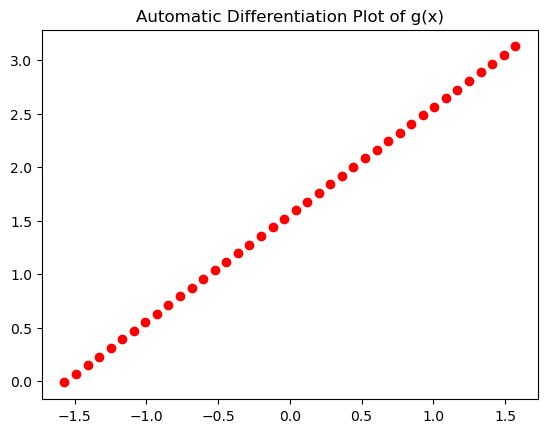

In [77]:
# part b
X_array = np.linspace(-np.pi/2,+np.pi/2,40) #defining our x-values

plt.plot(X_array, g(X_array), "ro") #plotting
plt.title("Automatic Differentiation Plot of g(x)")
plt.show()

Derivative at x = 0 is: 1.0


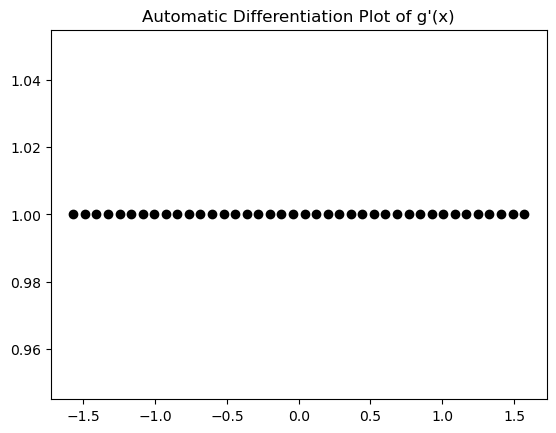

In [78]:
# part c

print("Derivative at x = 0 is:", Auto_Differentiation([0,1])[1]) #printing the derivative at x = 0

plt.plot(X_array, Auto_Differentiation([X_array,1])[1], "ko") #plotting the entire list of derivative values
plt.title("Automatic Differentiation Plot of g'(x)")
plt.show()


Notice that in Part B we suspect that the slope - and therefore first derivative - is constant, and that Part C agrees with this conclusion.